# Mistral-7B PGA v2 with Recall and Held-Out Evaluation (Standalone)

**Purpose.** A single Run-All that reproduces the released Mistral-7B PGA v2 pipeline and
adds the missing behavioural measurements: memorized-pool recall (log P per continuation
token) and token-weighted held-out perplexity, measured on the SAME model immediately before
and after PGA training. It also saves the LoRA adapter, which the released repo lacks. This
answers the reviewer request to scope PGA claims per variant (probe + recall + capability).

**Provenance.** The pool-build and PGA-v2 training cells below are taken verbatim from the
released `MLDU_E_mistral_kaggle_pipeline2.ipynb` (only the inline `!pip` lines were moved to
the setup cell). Hyperparameters are unchanged: LoRA r=8, lr 3e-5, 80 epochs, refit every 10,
lambda_align=0.05, lambda_ce=3.0, align layers [16, 20, 24, 28, 32], probe C=0.01, 6 contexts.

**Requirements.** GPU (T4 works; 4-bit NF4). Runs on Kaggle or Colab. The pool build takes
roughly 10 minutes and PGA training on the order of an hour on a T4. Outputs land in the
working directory: `mistral_pga_recall_eval.json`, `mldu_e_pga_mistral7b_v2.json`, the
adapter under `mistral7b_pga_v2_lora/`, and a 600-dpi summary figure.


In [1]:
import os, sys, subprocess, random
from pathlib import Path
import numpy as np
import torch
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers>=4.40',
                'accelerate', 'bitsandbytes>=0.46', 'peft>=0.18', 'scikit-learn'], check=True)
# Directory layout expected by the verbatim pipeline2 cells:
BASE = Path('/kaggle/working') if IN_KAGGLE else (Path('/content') if IN_COLAB else Path('.'))
DRIVE = BASE / 'MIDU'; DRIVE.mkdir(parents=True, exist_ok=True)
ART = DRIVE / 'MLDU_E' / 'artifacts'; ART.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE == 'cuda', 'This notebook needs a GPU (4-bit Mistral-7B).'
torch.manual_seed(42); np.random.seed(42); random.seed(42)
print('BASE =', BASE, '| DRIVE =', DRIVE, '| ART =', ART)


BASE = /content | DRIVE = /content/MIDU | ART = /content/MIDU/MLDU_E/artifacts


## 1. Pool build (verbatim from pipeline2)
Loads Mistral-7B in 4-bit as `m`, screens the 12 candidates by log P per continuation token, keeps the top 7, and saves `mistral_memorized.json` / `mistral_clean.json`.

In [2]:
# === GPU memory cleanup before loading Mistral-7B (4-bit needs ~5GB) ===
import gc, torch
# Drop any large models held by globals from earlier modules
for _v in list(globals()):
    _obj = globals().get(_v)
    if isinstance(_obj, torch.nn.Module):
        try: _obj.cpu()
        except Exception: pass
        del globals()[_v]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    free, total = torch.cuda.mem_get_info()
    print(f'GPU memory after cleanup: {free/1e9:.2f}GB free / {total/1e9:.2f}GB total')

# === MISTRAL-7B: BUILD ===
# 4-bit load, identifies memorized sequences by log-p per continuation token,
# keeps top-K, saves mistral_memorized.json + mistral_clean.json
# Requires HF_TOKEN secret in Colab for gated Mistral access

import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = None

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL  = 'mistralai/Mistral-7B-v0.1'   # or 'mistralai/Mistral-7B-Instruct-v0.2'
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                         bnb_4bit_compute_dtype=torch.bfloat16,
                         bnb_4bit_use_double_quant=True)
tok = AutoTokenizer.from_pretrained(MODEL, token=HF_TOKEN)
tok.pad_token = tok.eos_token
m = AutoModelForCausalLM.from_pretrained(
    MODEL, quantization_config=bnb, device_map='auto', token=HF_TOKEN
).eval()
print(f'Loaded {MODEL} (4-bit)')

# Candidate pool — Mistral was trained on a broader corpus (web + code + scientific)
# so includes more varied content than Pile-only models
CANDIDATES = [
    "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights",
    "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA 02110-1301 USA Everyone is permitted to copy and distribute verbatim copies of this license document,",
    "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law",
    "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions",
    "The MIT License (MIT) Copyright (c) 2016 Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction",
    "We the people of the United States, in order to form a more perfect union, establish justice, insure domestic tranquility, provide for the common defense, promote the general welfare, and secure the blessings of liberty",
    "Four score and seven years ago our fathers brought forth on this continent, a new nation, conceived in liberty, and dedicated to the proposition that all men are created equal. Now we are engaged in a great civil war",
    "To be, or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fortune, or to take arms against a sea of troubles, and by opposing end them.",
    "import numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, Dataset\n\nclass MyModel(nn.Module):\n    def __init__(self, input_dim, hidden_dim, output_dim):\n        super().__init__()",
    "#!/usr/bin/env python\n# -*- coding: utf-8 -*-\n\"\"\"\nThis module provides utility functions for data processing and analysis.\nAuthor: Example\nLicense: MIT\n\"\"\"\n\nimport os\nimport sys\nimport json\nimport logging\nfrom pathlib import Path",
    "Call me Ishmael. Some years ago, never mind how long precisely, having little or no money in this purse, and nothing particular to interest me on shore, I thought I would sail about a little and see the watery part of the world.",
    "In the beginning God created the heaven and the earth. And the earth was without form, and void; and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters.",
]

CLEAN_POOL = [
    "The research team conducted experiments with three different sample groups to evaluate the effectiveness of the new treatment protocol. Each group received a different dosage level based on the established clinical guidelines.",
    "Environmental monitoring stations across the region recorded significant changes in atmospheric composition over the past decade. Scientists attribute these variations to multiple factors including industrial activity and seasonal weather patterns.",
    "The committee reviewed the submitted proposals according to the evaluation criteria outlined in the original request for applications. Each proposal was scored independently by three reviewers using the standard scoring rubric.",
    "Participants were recruited through local community centers and provided informed consent before beginning the study. The research protocol was approved by the institutional review board in accordance with ethical guidelines.",
    "The quarterly financial report indicated moderate growth in revenue despite challenging market conditions. Management attributes this performance to strategic investments in product development and market expansion initiatives.",
    "Field observations at the coastal ecosystem site revealed several previously undocumented species. Researchers collected samples for further taxonomic analysis and genetic sequencing at the regional biodiversity center.",
    "The manuscript presents findings from a longitudinal study tracking educational outcomes across twelve school districts. Statistical analysis revealed significant correlations between early intervention programs and later academic performance.",
    "Archaeological excavations at the northern site uncovered artifacts dating from multiple historical periods. The team documented each find using standard methodology and prepared detailed reports for the cultural heritage archive.",
    "def process_data_stream(input_buffer, chunk_size, output_handler):\n    # This is a hypothetical processing function not in the training data\n    intermediate = []\n    for idx in range(0, len(input_buffer), chunk_size):\n        segment = input_buffer[idx:idx + chunk_size]",
    "def custom_data_pipeline_setup(source_path, target_directory, configuration_options):\n    # A fictional pipeline initialization routine\n    logger = setup_application_logger(configuration_options.log_level)\n    validation_result = perform_source_path_validation(source_path)",
    "Quarterly earnings exceeded analyst expectations by a substantial margin due to stronger than projected consumer demand in several key geographic regions. The chief executive officer credited the performance to successful product launches.",
    "The city council approved the proposed zoning amendment after extensive public comment and review by planning staff. Implementation will occur in phases over the next two years to allow for smooth transition.",
]
assert len(CANDIDATES) == len(CLEAN_POOL)

@torch.no_grad()
def log_p_per_token(text, n_prefix_tokens=10):
    ids = tok(text, return_tensors='pt').to(DEVICE).input_ids[0]
    if len(ids) <= n_prefix_tokens + 1: return float('nan')
    logits = m(ids.unsqueeze(0)).logits[0]
    logp = F.log_softmax(logits[:-1].float(), dim=-1)
    tgt = ids[1:]
    tok_logps = logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    return float(tok_logps[n_prefix_tokens-1:].mean().item())

print('\nlog_p per continuation token (higher = more memorized):')
scores = []
for i, t in enumerate(CANDIDATES):
    lp = log_p_per_token(t)
    scores.append((i, lp))
    print(f'  {i:2d}  log_p={lp:+.3f}  "{t[:80]}..."')

K = 7
keep_idx = sorted([s[0] for s in sorted(scores, key=lambda s: -s[1])[:K]])
MEM   = [CANDIDATES[i] for i in keep_idx]
CLEAN = [CLEAN_POOL[i] for i in keep_idx]

json.dump(MEM,   open(DRIVE / 'mistral_memorized.json', 'w'), indent=2)
json.dump(CLEAN, open(DRIVE / 'mistral_clean.json',     'w'), indent=2)
print(f'\nKept top {K} by log-p')
print(f'saved: {DRIVE / "mistral_memorized.json"}')
print(f'saved: {DRIVE / "mistral_clean.json"}')

GPU memory after cleanup: 84.65GB free / 85.09GB total


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loaded mistralai/Mistral-7B-v0.1 (4-bit)

log_p per continuation token (higher = more memorized):
   0  log_p=-0.391  "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of c..."
   1  log_p=-0.152  "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free So..."
   2  log_p=-0.086  "Licensed under the Apache License, Version 2.0 (the "License"); you may not use ..."
   3  log_p=-0.091  "Redistribution and use in source and binary forms, with or without modification,..."
   4  log_p=-0.291  "The MIT License (MIT) Copyright (c) 2016 Permission is hereby granted, free of c..."
   5  log_p=-0.029  "We the people of the United States, in order to form a more perfect union, estab..."
   6  log_p=-0.143  "Four score and seven years ago our fathers brought forth on this continent, a ne..."
   7  log_p=-0.187  "To be, or not to be, that is the question: whether 'tis nobler in the mind to su..."
   8  log_p=-0.405  "import numpy as np
import torch
i

## 2. Pre-PGA evaluation
Measured on the base 4-bit model (`m`) loaded by the pool-build cell, using the pools it just saved.

In [3]:
# Shared evaluation functions (identical convention pre/post: recall = mean log P per
# continuation token after a 10-token prefix; held-out PPL is token-weighted)
import torch.nn.functional as F
import numpy as np

HELD_OUT_20 = [
    'The committee will meet on Thursday to review the quarterly budget figures.',
    'Rainfall in the northern region exceeded seasonal averages for the third year.',
    'The museum opened a new exhibition of early photographic equipment.',
    'Local farmers reported strong harvests despite the late spring frost.',
    'The train service between the two cities resumes at the end of the month.',
    'Researchers catalogued several previously undescribed species of moss.',
    'The library extended its weekend opening hours after public consultation.',
    'A new bridge across the river reduced average commute times noticeably.',
    'The bakery on the corner sells out of sourdough loaves by mid-morning.',
    'Wind turbines along the ridge supply power to several thousand homes.',
    'The documentary traces the history of cartography from antiquity onward.',
    'Students presented their engineering projects at the annual showcase.',
    'The harbour was dredged last spring to accommodate larger vessels.',
    'Volunteers planted native shrubs along the restored riverbank.',
    'The observatory scheduled public viewing nights around the meteor shower.',
    'A regional airline added direct flights between the two coastal cities.',
    'The publisher announced a new series of translated short fiction.',
    'Beekeepers reported stable hive numbers after two difficult seasons.',
    'The clinic expanded its vaccination hours during the winter months.',
    'City engineers repaved the avenue and added a protected bicycle lane.',
]

@torch.no_grad()
def eval_logp_cont(mdl, text, n_prefix_tokens=10, max_len=256):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_len).input_ids[0].to(DEVICE)
    if len(ids) <= n_prefix_tokens + 1:
        return float('nan')
    logits = mdl(ids.unsqueeze(0)).logits[0]
    lp = F.log_softmax(logits[:-1].float(), dim=-1)
    tgt = ids[1:]
    tl = lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    return float(tl[n_prefix_tokens-1:].mean())

@torch.no_grad()
def eval_heldout(mdl, max_len=64):
    total_lp, total_n = 0.0, 0
    for s in HELD_OUT_20:
        ids = tok(s, return_tensors='pt', truncation=True, max_length=max_len).input_ids[0].to(DEVICE)
        logits = mdl(ids.unsqueeze(0)).logits[0]
        lp = F.log_softmax(logits[:-1].float(), dim=-1)
        tl = lp.gather(-1, ids[1:].unsqueeze(-1)).squeeze(-1)
        total_lp += float(tl.sum()); total_n += len(tl)
    mean_lp = total_lp / total_n
    return mean_lp, float(np.exp(-mean_lp))

def run_eval(mdl, tag, mem_texts, clean_texts):
    mdl.eval()
    recall = [eval_logp_cont(mdl, t) for t in mem_texts]
    clean_lp = [eval_logp_cont(mdl, t) for t in clean_texts]
    h_lp, h_ppl = eval_heldout(mdl)
    rec = {'tag': tag,
           'recall_logp_per_seq': recall, 'recall_logp_mean': float(np.nanmean(recall)),
           'clean_logp_mean': float(np.nanmean(clean_lp)),
           'held_out_logp_per_tok': h_lp, 'held_out_ppl_token_weighted': h_ppl}
    print(f"[{tag}] recall log P/tok {rec['recall_logp_mean']:+.4f} | "
          f"clean {rec['clean_logp_mean']:+.4f} | held-out log P {h_lp:+.4f} (ppl {h_ppl:.1f})")
    import json as _json, os as _os
    path = _os.path.join(str(BASE), 'mistral_pga_recall_eval.json')
    allr = _json.load(open(path)) if _os.path.exists(path) else {}
    allr[tag] = rec
    _json.dump(allr, open(path, 'w'), indent=1)
    print('saved ->', path)
    return rec

import json
MEM_TEXTS = json.load(open(DRIVE / 'mistral_memorized.json'))
CLEAN_TEXTS = json.load(open(DRIVE / 'mistral_clean.json'))
pre_rec = run_eval(m, 'pre', MEM_TEXTS, CLEAN_TEXTS)


[pre] recall log P/tok -0.1049 | clean -2.2975 | held-out log P -3.4090 (ppl 30.2)
saved -> /content/mistral_pga_recall_eval.json


## 3. PGA v2 training (verbatim from pipeline2)
Begins with pipeline2's own GPU-cleanup block (which releases the pool-build model), reloads Mistral 4-bit as `base`, wraps it with LoRA as `model`, and trains PGA v2. Prints per-layer LOO probe values before and after, and saves `mldu_e_pga_mistral7b_v2.json`.

In [4]:
# === GPU memory cleanup before loading Mistral-7B (4-bit needs ~5GB) ===
import gc, torch
# Drop any large models held by globals from earlier modules
for _v in list(globals()):
    _obj = globals().get(_v)
    if isinstance(_obj, torch.nn.Module):
        try: _obj.cpu()
        except Exception: pass
        del globals()[_v]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    free, total = torch.cuda.mem_get_info()
    print(f'GPU memory after cleanup: {free/1e9:.2f}GB free / {total/1e9:.2f}GB total')

# === MISTRAL-7B PGA — V2 with late-layer coverage + context augmentation ===

import os, json, time, math, random
import numpy as np, torch, torch.nn.functional as F
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ART = DRIVE / 'MLDU_E' / 'artifacts'; ART.mkdir(parents=True, exist_ok=True)
try: HF_TOKEN = userdata.get('HF_TOKEN')
except Exception: HF_TOKEN = None

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42); np.random.seed(42); random.seed(42)

MODEL_NAME    = 'mistralai/Mistral-7B-v0.1'
PROBE_LAYER   = 24
N_HIDDEN      = 33
MAX_LEN       = 256
LORA_R        = 8             # down from 16 — less overfit capacity
LR            = 3e-5          # slower
EPOCHS        = 80
REFIT_EVERY   = 10            # more frequent
LAMBDA_ALIGN  = 0.05          # down from 1.0 to prevent CE collapse
LAMBDA_CE     = 3.0           # up from 1.0 to protect capability
ALIGN_LAYERS  = [16, 20, 24, 28, 32]   # includes LATE layers (30→32 region)
PROBE_C       = 0.01          # strong L2 regularization
GRAD_CLIP     = 1.0

CONTEXTS = ["", "The following text: ", "Excerpt: ", "Here is a passage: ",
            "Document reads: ", "Archive entry: "]
K_CTX = len(CONTEXTS)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                         bnb_4bit_compute_dtype=torch.bfloat16,
                         bnb_4bit_use_double_quant=True)
tok = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb, device_map='auto', token=HF_TOKEN
)
print(f'Loaded {MODEL_NAME} (4-bit)')

MEM_RAW   = json.load(open(DRIVE / 'mistral_memorized.json'))
CLEAN_RAW = json.load(open(DRIVE / 'mistral_clean.json'))
assert len(MEM_RAW) == len(CLEAN_RAW)
N_SEQ = len(MEM_RAW)
MEM   = [ctx + s for s in MEM_RAW   for ctx in CONTEXTS]
CLEAN = [ctx + s for s in CLEAN_RAW for ctx in CONTEXTS]
ALL = MEM + CLEAN
N_AUG = len(MEM)
Y = np.array([1]*N_AUG + [0]*N_AUG)
SEQ_IDX = np.array([i for i in range(N_SEQ) for _ in range(K_CTX)] * 2)
print(f'  N_SEQ={N_SEQ}, K_CTX={K_CTX}, N_total={2*N_AUG}')

@torch.no_grad()
def acts_at_layer(m, texts, layer):
    out = []
    for t in texts:
        ids = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h = m(**ids, output_hidden_states=True).hidden_states[layer][0, -1, :]
        out.append(h.cpu().float().numpy())
    return np.array(out)

def loo_probe(X, y, seq_idx):
    accs = []
    for i in range(N_SEQ):
        te = (seq_idx == i)
        sc = StandardScaler(); Xtr = sc.fit_transform(X[~te]); Xte = sc.transform(X[te])
        accs.append(LogisticRegression(max_iter=10000, C=PROBE_C, random_state=42)
                    .fit(Xtr, y[~te]).score(Xte, y[te]))
    return float(np.mean(accs))

def fit_w(X, y):
    sc = StandardScaler(); Xn = sc.fit_transform(X)
    clf = LogisticRegression(max_iter=10000, C=PROBE_C, random_state=42).fit(Xn, y)
    w = clf.coef_[0] / sc.scale_; return w / (np.linalg.norm(w) + 1e-12)

print('\n=== BASELINE LOO probe at sampled layers ===')
base.eval(); pre = {}
SAMPLE_LAYERS = [0, 8, 16, 20, 24, 28, 30, 32]
for L in SAMPLE_LAYERS:
    pre[L] = loo_probe(acts_at_layer(base, ALL, L), Y, SEQ_IDX)
    print(f'  layer {L}: {pre[L]:.3f}')

base = prepare_model_for_kbit_training(base)
lora_cfg = LoraConfig(task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=2*LORA_R,
                     target_modules=['q_proj','k_proj','v_proj','o_proj',
                                     'gate_proj','up_proj','down_proj'],
                     lora_dropout=0.0, bias='none')
model = get_peft_model(base, lora_cfg); model.print_trainable_parameters()

def refit_w_layers(m, layers):
    m.eval(); out = {}
    for L in layers:
        X = acts_at_layer(m, ALL, L)
        out[L] = torch.as_tensor(fit_w(X, Y), dtype=torch.bfloat16, device=DEVICE)
    m.train(); return out

def pga_step(m, opt, w_per_layer, layers):
    m.train(); opt.zero_grad()
    align = 0.0; ce = 0.0
    ctx_pick = random.choices(range(K_CTX), k=N_SEQ)
    for i in range(N_SEQ):
        mem_text = MEM[i * K_CTX + ctx_pick[i]]
        cln_text = CLEAN[i * K_CTX + ctx_pick[i]]
        m_ids = tok(mem_text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        c_ids = tok(cln_text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        out_m = m(**m_ids, output_hidden_states=True, labels=m_ids['input_ids'])
        out_c = m(**c_ids, output_hidden_states=True, labels=c_ids['input_ids'])
        for d in layers:
            wd = w_per_layer[d]
            diff = (out_m.hidden_states[d][0, -1, :].to(torch.bfloat16) -
                    out_c.hidden_states[d][0, -1, :].to(torch.bfloat16))
            align = align + (diff @ wd).to(torch.float32) ** 2
        ce = ce + out_c.loss.to(torch.float32)
    align = align / (N_SEQ * len(layers)); ce = ce / N_SEQ
    loss = LAMBDA_ALIGN * align + LAMBDA_CE * ce
    loss.backward()
    torch.nn.utils.clip_grad_norm_([p for p in m.parameters() if p.requires_grad], GRAD_CLIP)
    opt.step()
    return float(align.item()), float(ce.item())

opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
print(f'\n=== PGA v2 (Mistral-7B LoRA r={LORA_R}, align layers {ALIGN_LAYERS}) ===')
t0 = time.time()
w_per_layer = refit_w_layers(model, ALIGN_LAYERS)
for ep in range(1, EPOCHS + 1):
    if ep > 1 and (ep - 1) % REFIT_EVERY == 0:
        w_per_layer = refit_w_layers(model, ALIGN_LAYERS)
    al, ce = pga_step(model, opt, w_per_layer, ALIGN_LAYERS)
    if ep % 10 == 0 or ep == 1:
        model.eval()
        probe_at = loo_probe(acts_at_layer(model, ALL, PROBE_LAYER), Y, SEQ_IDX)
        model.train()
        print(f'ep {ep:3d}  align {al:.3f}  ce {ce:.3f}  '
              f'probe@L{PROBE_LAYER} {probe_at:.3f}  elapsed {time.time()-t0:.0f}s')

print('\n=== POST-PGA LOO probe at sampled layers ===')
model.eval(); post = {}
for L in sorted(set(SAMPLE_LAYERS + ALIGN_LAYERS)):
    post[L] = loo_probe(acts_at_layer(model, ALL, L), Y, SEQ_IDX)
    if L in pre:
        print(f'  layer {L}: pre {pre[L]:.3f} -> post {post[L]:.3f}  (Δ {post[L]-pre[L]:+.3f})')
    else:
        print(f'  layer {L}: post {post[L]:.3f}  (align-layer only)')

json.dump({'model': MODEL_NAME, 'version': 'v2_ctx_augmented_late_layers',
           'lora_r': LORA_R, 'epochs': EPOCHS, 'lambda_align': LAMBDA_ALIGN,
           'lambda_ce': LAMBDA_CE, 'probe_C': PROBE_C, 'n_contexts': K_CTX,
           'align_layers': ALIGN_LAYERS,
           'pre_per_layer': {str(k): float(v) for k, v in pre.items()},
           'post_per_layer': {str(k): float(v) for k, v in post.items()}},
          open(ART / 'mldu_e_pga_mistral7b_v2.json', 'w'), indent=2)
print(f'saved: {ART / "mldu_e_pga_mistral7b_v2.json"}')

GPU memory after cleanup: 80.53GB free / 85.09GB total


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-v0.1 (4-bit)
  N_SEQ=7, K_CTX=6, N_total=84

=== BASELINE LOO probe at sampled layers ===
  layer 0: 0.857
  layer 8: 1.000
  layer 16: 1.000
  layer 20: 1.000
  layer 24: 0.988
  layer 28: 1.000
  layer 30: 1.000
  layer 32: 1.000
trainable params: 20,971,520 || all params: 7,262,703,616 || trainable%: 0.2888

=== PGA v2 (Mistral-7B LoRA r=8, align layers [16, 20, 24, 28, 32]) ===


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


ep   1  align 44.969  ce 3.033  probe@L24 0.988  elapsed 94s


...

ep  60  align 0.564  ce 0.209  probe@L24 0.381  elapsed 995s


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


ep  70  align 0.354  ce 0.248  probe@L24 0.381  elapsed 1158s


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


ep  80  align 0.205  ce 0.252  probe@L24 0.417  elapsed 1321s

=== POST-PGA LOO probe at sampled layers ===
  layer 0: pre 0.857 -> post 0.857  (Δ +0.000)
  layer 8: pre 1.000 -> post 0.881  (Δ -0.119)
  layer 16: pre 1.000 -> post 0.738  (Δ -0.262)
  layer 20: pre 1.000 -> post 0.583  (Δ -0.417)
  layer 24: pre 0.988 -> post 0.417  (Δ -0.571)
  layer 28: pre 1.000 -> post 0.417  (Δ -0.583)
  layer 30: pre 1.000 -> post 0.655  (Δ -0.345)
  layer 32: pre 1.000 -> post 0.714  (Δ -0.286)
saved: /content/MIDU/MLDU_E/artifacts/mldu_e_pga_mistral7b_v2.json


## 4. Post-PGA evaluation, adapter save, and summary

In [5]:
# The v2 cell's cleanup deleted earlier globals; re-declare eval helpers' dependencies
# were kept as plain functions above, but the cleanup block removes nn.Modules only, so the
# eval functions and pools are still defined. Evaluate the trained PGA model (`model`).
post_rec = run_eval(model, 'post', MEM_TEXTS, CLEAN_TEXTS)

# Save the LoRA adapter (missing from the released repo)
ADAPTER_DIR = str(BASE / 'mistral7b_pga_v2_lora')
model.save_pretrained(ADAPTER_DIR)
print('adapter saved ->', ADAPTER_DIR)

drop = pre_rec['recall_logp_mean'] - post_rec['recall_logp_mean']
ppl_ratio = post_rec['held_out_ppl_token_weighted'] / pre_rec['held_out_ppl_token_weighted']
clean_shift = post_rec['clean_logp_mean'] - pre_rec['clean_logp_mean']
print('\n=== SUMMARY (for the rebuttal / revision) ===')
print(f"recall log P/tok: {pre_rec['recall_logp_mean']:+.4f} -> "
      f"{post_rec['recall_logp_mean']:+.4f}  (drop {drop:+.3f} nats)")
print(f"held-out PPL (token-weighted): {pre_rec['held_out_ppl_token_weighted']:.1f} -> "
      f"{post_rec['held_out_ppl_token_weighted']:.1f}  (ratio {ppl_ratio:.3f})")
print(f"clean-pool log P shift: {clean_shift:+.4f}")
print('Report these alongside the pre/post probe table printed by the training cell. If the\n'
      'recall drop is small, scope the Mistral PGA claim as representational (probe-level)\n'
      'with recall preserved, and state that explicitly.')


[post] recall log P/tok -2.7311 | clean -0.0002 | held-out log P -4.1333 (ppl 62.4)
saved -> /content/mistral_pga_recall_eval.json
adapter saved -> /content/mistral7b_pga_v2_lora

=== SUMMARY (for the rebuttal / revision) ===
recall log P/tok: -0.1049 -> -2.7311  (drop +2.626 nats)
held-out PPL (token-weighted): 30.2 -> 62.4  (ratio 2.063)
clean-pool log P shift: +2.2974
Report these alongside the pre/post probe table printed by the training cell. If the
recall drop is small, scope the Mistral PGA claim as representational (probe-level)
with recall preserved, and state that explicitly.


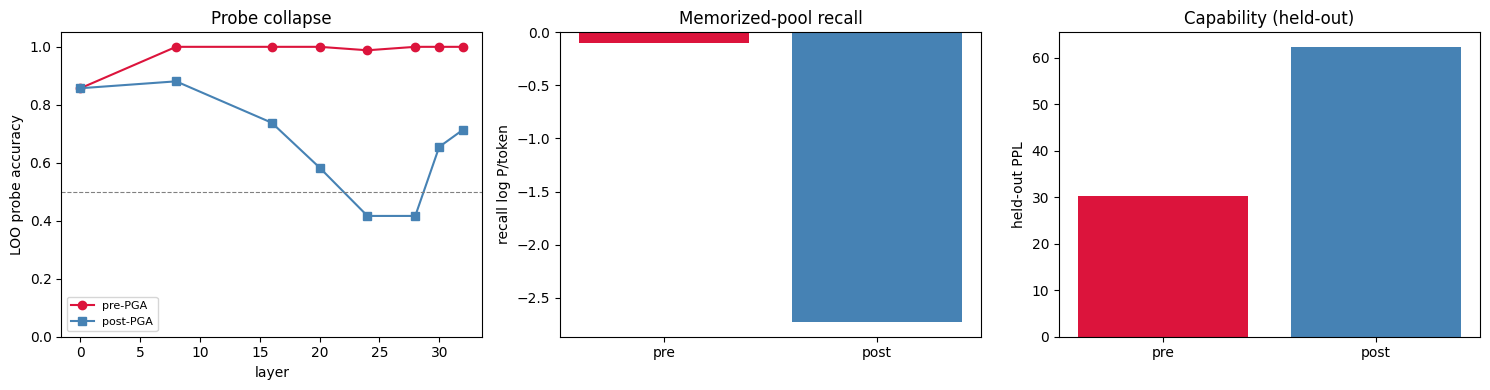

saved fig_mistral_pga_recall_eval.{png,pdf}


In [6]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
layers = sorted(set(int(k) for k in pre))
axes[0].plot(layers, [pre[L] for L in layers], marker='o', color='crimson', label='pre-PGA')
post_layers = sorted(set(int(k) for k in post))
axes[0].plot(post_layers, [post[L] for L in post_layers], marker='s', color='steelblue', label='post-PGA')
axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)
axes[0].set_xlabel('layer'); axes[0].set_ylabel('LOO probe accuracy'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Probe collapse'); axes[0].legend(fontsize=8)
axes[1].bar([0, 1], [pre_rec['recall_logp_mean'], post_rec['recall_logp_mean']],
            color=['crimson', 'steelblue'])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['pre', 'post'])
axes[1].set_ylabel('recall log P/token'); axes[1].set_title('Memorized-pool recall')
axes[2].bar([0, 1], [pre_rec['held_out_ppl_token_weighted'],
                     post_rec['held_out_ppl_token_weighted']], color=['crimson', 'steelblue'])
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['pre', 'post'])
axes[2].set_ylabel('held-out PPL'); axes[2].set_title('Capability (held-out)')
plt.tight_layout()
plt.savefig(str(BASE / 'fig_mistral_pga_recall_eval.png'), dpi=600, bbox_inches='tight')
plt.savefig(str(BASE / 'fig_mistral_pga_recall_eval.pdf'), bbox_inches='tight')
plt.show()
print('saved fig_mistral_pga_recall_eval.{png,pdf}')


## Reporting notes

All measurements here are on the 4-bit model, consistent between pre and post (the
comparison is internally valid); do not compare absolute PPL levels against fp16 runs.
The per-layer probe values printed by the training cell should match the released
`mldu_e_pga_mistral7b_v2.json` within run-to-run variation (LoRA training on GPU is not
bit-deterministic); if they differ qualitatively (e.g., no mid-layer collapse), stop and
investigate before reporting the recall/PPL numbers.
